## Setup

This section loads configuration, discovers the latest run for each experiment under `data/04-predictions/`, and defines utility functions used throughout the notebook.

Design goals:
- No hard-coded absolute paths (workspace-relative only).
- Deterministic behavior via explicit random seeds.
- Robust loading: if an optional artifact is missing, the notebook continues with a clear message.

In [2]:
from __future__ import annotations

import numpy as np

# Compatibility shim for NumPy 2.x + some Keras internals:
# Avoids FutureWarning triggered by `hasattr(np, "object")` during import time.
if "object" not in np.__dict__:
    np.object = np.object_  # type: ignore[attr-defined]

In [3]:
from __future__ import annotations

import json
import os
import random
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp
import tensorflow as tf
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
)

# ----------------------------
# Reproducibility
# ----------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ----------------------------
# Paths
# ----------------------------
NOTEBOOK_STEM = "analysis_2025-12-23_09-48"

def find_project_root(start: Path) -> Path:
    """Find the workspace root by searching upward for key folders.

    Parameters
    ----------
    start:
        Starting directory (typically Path.cwd()).

    Returns
    -------
    Path
        The detected project root.
"""

    current = start.resolve()
    for _ in range(10):
        if (current / "data").exists() and (current / "config").exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError("Could not locate project root containing data/ and config/")

PROJECT_ROOT = find_project_root(Path.cwd())
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
CHARTS_DIR = NOTEBOOKS_DIR / NOTEBOOK_STEM
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_PATH = PROJECT_ROOT / "config" / "huffpost_category_text.json"
with CONFIG_PATH.open("r", encoding="utf-8") as f:
    CONFIG: Dict[str, Any] = json.load(f)

PALETTE: List[str] = list(CONFIG.get("visualization", {}).get("color_palette", []))
if not PALETTE:
    # Fallback palette (used only if config is missing).
    PALETTE = ["#4a8ab8", "#1f4f75", "#d3d3d3"]

PREDICTIONS_ROOT = PROJECT_ROOT / Path(str(CONFIG["paths"]["predictions_dir"]))
FEATURES_DIR = PROJECT_ROOT / Path(str(CONFIG["paths"]["features_dir"]))
PREPROCESSED_DIR = PROJECT_ROOT / Path(str(CONFIG["paths"]["preprocessed_dir"]))

LABEL_ENCODER_PATH = FEATURES_DIR / str(CONFIG["paths"]["features_label_encoder_filename"])
LABEL_ENCODER = joblib.load(LABEL_ENCODER_PATH)
CLASS_NAMES: List[str] = [str(c) for c in LABEL_ENCODER.classes_.tolist()]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PREDICTIONS_ROOT:", PREDICTIONS_ROOT)
print("CHARTS_DIR:", CHARTS_DIR)
print("#classes:", len(CLASS_NAMES))

RUN_ID_RE = re.compile(r"^\d{8}T\d{6}Z$")

@dataclass(frozen=True)
class ExperimentRun:
    """Represents the latest run directory for an experiment."""

    experiment: str
    run_dir: Path

def _latest_run_dir(exp_dir: Path) -> Optional[Path]:
    """Pick the latest run directory for an experiment."""

    if not exp_dir.exists() or not exp_dir.is_dir():
        return None

    candidates = [p for p in exp_dir.iterdir() if p.is_dir()]
    if not candidates:
        return None

    timestamped = [p for p in candidates if RUN_ID_RE.match(p.name)]
    if timestamped:
        # UTC run ids sort lexicographically.
        return sorted(timestamped, key=lambda p: p.name)[-1]

    # Fallback: most recently modified directory.
    return max(candidates, key=lambda p: p.stat().st_mtime)

def discover_latest_experiments(pred_root: Path) -> List[ExperimentRun]:
    """Discover experiments and pick the latest run for each."""

    runs: List[ExperimentRun] = []
    if not pred_root.exists():
        return runs

    for exp_dir in sorted([p for p in pred_root.iterdir() if p.is_dir()]):
        run_dir = _latest_run_dir(exp_dir)
        if run_dir is None:
            continue
        runs.append(ExperimentRun(experiment=exp_dir.name, run_dir=run_dir))
    return runs

EXPERIMENTS = discover_latest_experiments(PREDICTIONS_ROOT)
for r in EXPERIMENTS:
    print(f"- {r.experiment}: {r.run_dir.name}")

def load_metrics_json(path: Path) -> Dict[str, Any]:
    """Load a metrics JSON artifact (if present)."""

    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def load_predictions_csv(path: Path) -> pd.DataFrame:
    """Load a standard predictions CSV artifact."""

    if not path.exists():
        raise FileNotFoundError(str(path))
    df = pd.read_csv(path)
    required = {"y_true", "y_pred"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Predictions file missing required columns: {missing}")
    return df

def compute_overall_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Compute a richer set of overall metrics than what is persisted."""

    acc = float(accuracy_score(y_true, y_pred))
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="micro", zero_division=0
    )
    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision_macro": float(p_macro),
        "recall_macro": float(r_macro),
        "f1_macro": float(f_macro),
        "precision_micro": float(p_micro),
        "recall_micro": float(r_micro),
        "f1_micro": float(f_micro),
        "precision_weighted": float(p_weighted),
        "recall_weighted": float(r_weighted),
        "f1_weighted": float(f_weighted),
    }

def save_fig(fig: plt.Figure, filename: str) -> Path:
    """Save a matplotlib figure as a PNG in the notebook-named folder."""

    safe_name = re.sub(r"[^a-zA-Z0-9_.-]+", "_", filename)
    path = CHARTS_DIR / safe_name
    fig.savefig(path, dpi=160, bbox_inches="tight")
    return path

def plot_train_valid_bars(
    values: Mapping[str, float],
    *,
    title: str,
    ylabel: str,
    filename: str,
) -> None:
    """Plot a simple Train vs Validation bar chart and save it."""

    fig, ax = plt.subplots(figsize=(6, 4))
    keys = ["train", "valid"]
    vals = [float(values.get(k, np.nan)) for k in keys]
    ax.bar(keys, vals, color=[PALETTE[3], PALETTE[5]])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    save_fig(fig, filename)
    plt.show()

def plot_confusion_matrix_png(
    cm: np.ndarray,
    class_names: List[str],
    *,
    title: str,
    filename: str,
    normalize: bool = True,
) -> None:
    """Plot a (optionally normalized) confusion matrix and save it."""

    cm_arr = np.array(cm, dtype=float)
    if normalize:
        row_sums = cm_arr.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm_arr = cm_arr / row_sums

    cmap = LinearSegmentedColormap.from_list(
        "custom_cm",
        [PALETTE[0], PALETTE[5]],
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_arr, aspect="auto", cmap=cmap)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    fig.tight_layout()
    save_fig(fig, filename)
    plt.show()

def _softmax_np(logits: np.ndarray) -> np.ndarray:
    logits = np.asarray(logits, dtype=float)
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / np.sum(exp, axis=1, keepdims=True)

def load_tfidf_features() -> Dict[str, Any]:
    """Load TF-IDF feature matrices and label arrays used by TF-IDF experiments."""

    x_train = sp.load_npz(FEATURES_DIR / str(CONFIG["paths"]["features_x_train_filename"]))
    x_valid = sp.load_npz(FEATURES_DIR / str(CONFIG["paths"]["features_x_valid_filename"]))
    x_test = sp.load_npz(FEATURES_DIR / str(CONFIG["paths"]["features_x_test_filename"]))

    y_train = np.load(FEATURES_DIR / str(CONFIG["paths"]["features_y_train_filename"]))
    y_valid = np.load(FEATURES_DIR / str(CONFIG["paths"]["features_y_valid_filename"]))
    y_test = np.load(FEATURES_DIR / str(CONFIG["paths"]["features_y_test_filename"]))

    return {
        "x_train": x_train,
        "x_valid": x_valid,
        "x_test": x_test,
        "y_train": y_train,
        "y_valid": y_valid,
        "y_test": y_test,
    }

def load_preprocessed_splits() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load preprocessed train/valid/test CSV splits used by BERT experiments."""

    df_train = pd.read_csv(PREPROCESSED_DIR / str(CONFIG["paths"]["preprocessed_train_filename"]))
    df_valid = pd.read_csv(PREPROCESSED_DIR / str(CONFIG["paths"]["preprocessed_valid_filename"]))
    df_test = pd.read_csv(PREPROCESSED_DIR / str(CONFIG["paths"]["preprocessed_test_filename"]))
    return df_train, df_valid, df_test

PROJECT_ROOT: D:\repos\ml_classification_example
PREDICTIONS_ROOT: D:\repos\ml_classification_example\data\04-predictions\huffpost
CHARTS_DIR: D:\repos\ml_classification_example\notebooks\analysis_2025-12-23_09-48
#classes: 41
- distilbert_frozen: 20251222T190244Z
- distilbert_unfrozen: 20251223T010101Z
- tfidf_dense: 20251222T184926Z
- tfidf_logreg: 20251222T183959Z


## A.1 — Dataset & Evaluation Strategy

The HuffPost dataset is split into train/validation/test using a stratified strategy (`train_ratio=0.8`, `valid_ratio=0.1`, `test_ratio=0.1`) with a fixed seed (`random_seed=42`).

- **Validation split** is used during model development to tune hyperparameters and make early-stopping decisions.
- **Test split** remains untouched until the end, and is used once per experiment to estimate generalization performance.

For multi-class classification with many categories and potential class imbalance, **macro-averaged F1** is a key metric because it weights all classes equally; accuracy alone can hide poor performance on rare classes. We also report micro and weighted F1 for completeness.

### Dataset snapshot

The cell below loads the preprocessed splits and prints basic counts. This verifies that the train/valid/test separation is intact and provides context for interpreting metrics.

In [4]:
df_train, df_valid, df_test = load_preprocessed_splits()
text_col = str(CONFIG["schema"]["text_col"])
label_col = str(CONFIG["schema"]["label_col"])

def split_summary(df: pd.DataFrame, name: str) -> pd.Series:
    return pd.Series(
        {
            "split": name,
            "rows": int(len(df)),
            "unique_labels": int(df[label_col].nunique()),
            "pct_empty_text": float((df[text_col].astype(str).str.strip() == "").mean()),
        }
    )

summary = pd.DataFrame([
    split_summary(df_train, "train"),
    split_summary(df_valid, "valid"),
    split_summary(df_test, "test"),
])
summary

,split,rows,unique_labels,pct_empty_text
0,train,160681,41,0.0
1,valid,20086,41,0.0
2,test,20086,41,0.0


## A.2 — Training & Validation Analysis

The training pipelines in this workspace persist **final** validation/test metrics and predictions, but they do not currently persist per-epoch training logs (e.g., Keras `History`).

To still diagnose under/overfitting in a reproducible way, we compute **post-hoc Train vs Validation** metrics for each saved model (where possible):
- **Train vs Validation loss**: multiclass cross-entropy (log loss) computed from model probabilities.
- **Train vs Validation accuracy / macro-F1**: computed from predicted labels.

Each plot is saved as a PNG inside the notebook-named folder under `notebooks/`.

### Post-hoc Train vs Validation plots

The next cell loops over the latest run of each experiment and generates two plots per experiment:
- Train vs validation cross-entropy (log loss)
- Train vs validation accuracy and macro-F1

These plots help spot overfitting (train much better than validation) even when per-epoch curves are not saved.

#### distilbert_frozen — latest run `20251222T190244Z`

**What this shows:** A post-hoc comparison of Train vs Validation performance for the saved model.**Why it matters:** Large gaps can indicate overfitting; close alignment suggests better generalization.

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


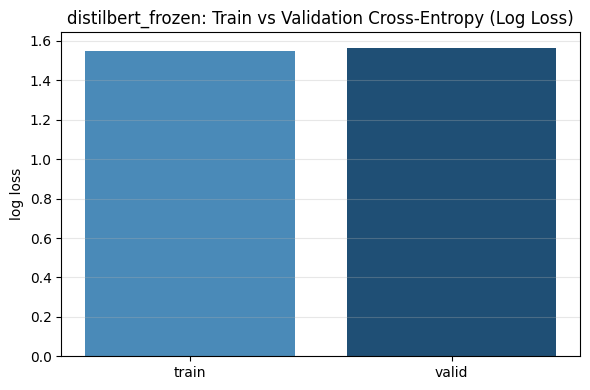

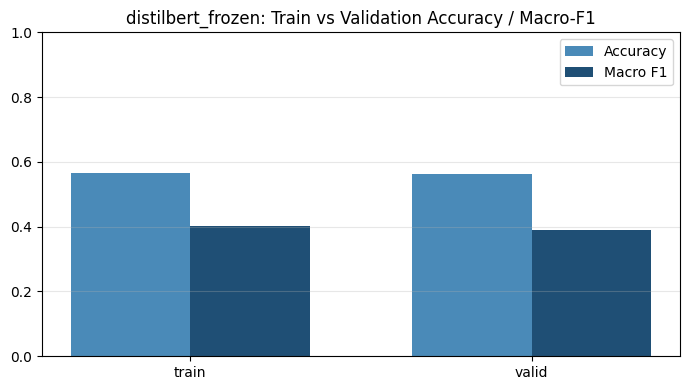

#### distilbert_unfrozen — latest run `20251223T010101Z`

**What this shows:** A post-hoc comparison of Train vs Validation performance for the saved model.**Why it matters:** Large gaps can indicate overfitting; close alignment suggests better generalization.

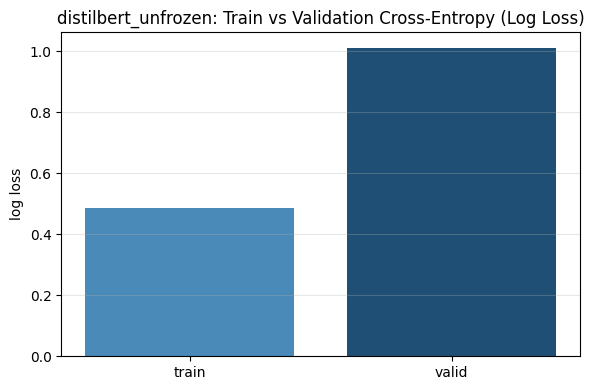

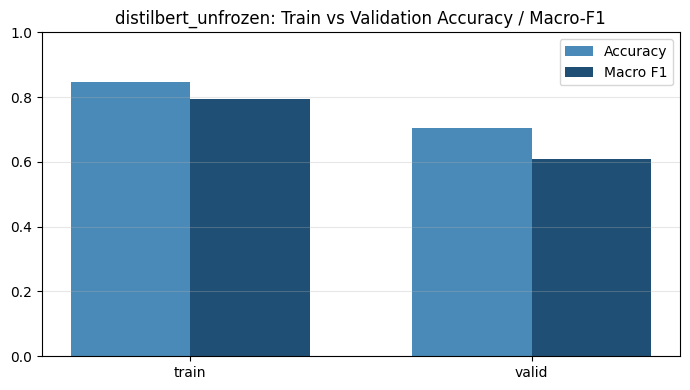

#### tfidf_dense — latest run `20251222T184926Z`

**What this shows:** A post-hoc comparison of Train vs Validation performance for the saved model.**Why it matters:** Large gaps can indicate overfitting; close alignment suggests better generalization.

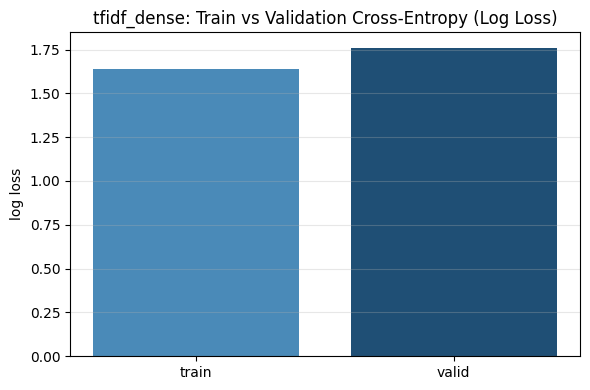

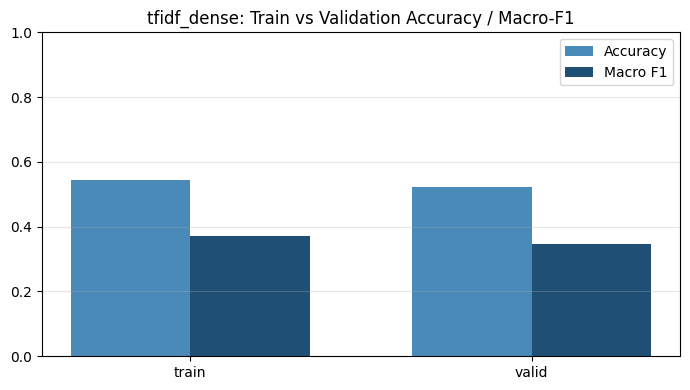

#### tfidf_logreg — latest run `20251222T183959Z`

**What this shows:** A post-hoc comparison of Train vs Validation performance for the saved model.**Why it matters:** Large gaps can indicate overfitting; close alignment suggests better generalization.

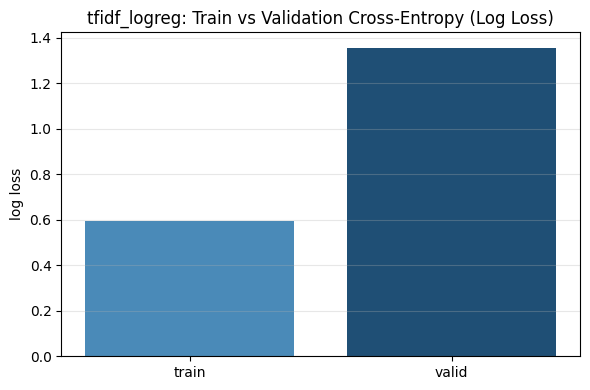

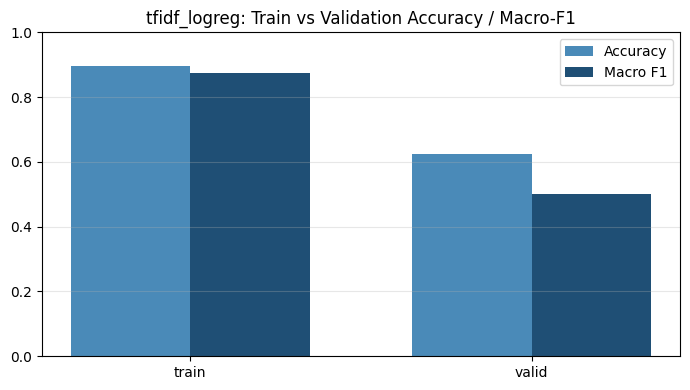

In [5]:
from IPython.display import Markdown, display

BERT_TRAIN_MAX_ROWS = 5000  # Set to None to evaluate on full train split (may be slow on CPU).
BERT_VALID_MAX_ROWS = None

def _maybe_sample_df(df: pd.DataFrame, max_rows: Optional[int], *, seed: int) -> pd.DataFrame:
    if max_rows is None or len(df) <= max_rows:
        return df
    return df.sample(n=int(max_rows), random_state=int(seed)).reset_index(drop=True)

def _encode_bert_texts(tokenizer: Any, text_arr: np.ndarray, *, max_length: int) -> Dict[str, tf.Tensor]:
    enc = tokenizer(
        text_arr.tolist(),
        truncation=True,
        padding="max_length",
        max_length=int(max_length),
        return_tensors="tf",
    )
    return {
        "token_ids": tf.cast(enc["input_ids"], tf.int32),
        "padding_mask": tf.cast(enc["attention_mask"], tf.int32),
    }

def evaluate_tfidf_logreg_posthoc(run_dir: Path) -> Dict[str, Dict[str, float]]:
    features = load_tfidf_features()
    model = joblib.load(run_dir / "model.joblib")

    out: Dict[str, Dict[str, float]] = {}
    for split in ("train", "valid"):
        x = features[f"x_{split}"]
        y_true = np.asarray(features[f"y_{split}"], dtype=int)
        probs = model.predict_proba(x)
        y_pred = np.asarray(np.argmax(probs, axis=1), dtype=int)
        out[split] = {
            **compute_overall_metrics(y_true, y_pred),
            "log_loss": float(log_loss(y_true, probs, labels=list(range(len(CLASS_NAMES))))),
        }
    return out

def evaluate_tfidf_dense_posthoc(run_dir: Path) -> Dict[str, Dict[str, float]]:
    features = load_tfidf_features()
    svd = joblib.load(run_dir / "svd.joblib")
    model = tf.keras.models.load_model(run_dir / "keras_model.keras")

    out: Dict[str, Dict[str, float]] = {}
    for split in ("train", "valid"):
        x_sparse = features[f"x_{split}"]
        y_true = np.asarray(features[f"y_{split}"], dtype=int)
        x_dense = svd.transform(x_sparse)
        logits = np.asarray(model.predict(x_dense, verbose=0))
        probs = _softmax_np(logits)
        y_pred = np.asarray(np.argmax(probs, axis=1), dtype=int)
        out[split] = {
            **compute_overall_metrics(y_true, y_pred),
            "log_loss": float(log_loss(y_true, probs, labels=list(range(len(CLASS_NAMES))))),
        }
    return out

def evaluate_distilbert_posthoc(run_dir: Path, *, max_length: int) -> Dict[str, Dict[str, float]]:
    from transformers import AutoTokenizer

    df_train_local, df_valid_local, _df_test_local = load_preprocessed_splits()
    df_train_local = _maybe_sample_df(df_train_local, BERT_TRAIN_MAX_ROWS, seed=RANDOM_SEED)
    df_valid_local = _maybe_sample_df(df_valid_local, BERT_VALID_MAX_ROWS, seed=RANDOM_SEED)

    y_train = LABEL_ENCODER.transform(df_train_local[label_col].fillna("").astype("string"))
    y_valid = LABEL_ENCODER.transform(df_valid_local[label_col].fillna("").astype("string"))

    text_train = df_train_local[text_col].fillna("").astype("string").to_numpy()
    text_valid = df_valid_local[text_col].fillna("").astype("string").to_numpy()

    tokenizer = AutoTokenizer.from_pretrained(run_dir / "tokenizer")
    model = tf.keras.models.load_model(run_dir / "keras_model.keras")

    out: Dict[str, Dict[str, float]] = {}
    for split, text_arr, y_true in (
        ("train", text_train, y_train),
        ("valid", text_valid, y_valid),
    ):
        x = _encode_bert_texts(tokenizer, text_arr, max_length=int(max_length))
        ds = tf.data.Dataset.from_tensor_slices(x).batch(int(CONFIG["training"]["batch_size"]))
        logits = np.asarray(model.predict(ds, verbose=0))
        probs = _softmax_np(logits)
        y_pred = np.asarray(np.argmax(probs, axis=1), dtype=int)
        out[split] = {
            **compute_overall_metrics(np.asarray(y_true, dtype=int), y_pred),
            "log_loss": float(log_loss(y_true, probs, labels=list(range(len(CLASS_NAMES))))),
        }
    return out

def posthoc_train_valid_for_experiment(run: ExperimentRun) -> Optional[Dict[str, Dict[str, float]]]:
    """Compute train/valid post-hoc metrics, if the required artifacts exist."""

    exp = run.experiment
    run_dir = run.run_dir

    try:
        if exp == "tfidf_logreg":
            return evaluate_tfidf_logreg_posthoc(run_dir)
        if exp == "tfidf_dense":
            return evaluate_tfidf_dense_posthoc(run_dir)
        if exp in ("distilbert_frozen", "distilbert_unfrozen"):
            valid_meta = load_metrics_json(run_dir / "metrics_valid.json").get("extra", {})
            max_length = int(valid_meta.get("max_length", CONFIG.get("experiments", {}).get("distilbert", {}).get("max_length", 64)))
            return evaluate_distilbert_posthoc(run_dir, max_length=max_length)
    except Exception as e:
        print(f"[WARN] Post-hoc evaluation failed for {exp}: {e}")
        return None

    print(f"[WARN] Unknown experiment type: {exp}")
    return None

for run in EXPERIMENTS:
    exp = run.experiment
    display(Markdown(f"#### {exp} — latest run `{run.run_dir.name}`"))

    display(Markdown(
        "**What this shows:** A post-hoc comparison of Train vs Validation performance for the saved model."
        "**Why it matters:** Large gaps can indicate overfitting; close alignment suggests better generalization."
    ))

    posthoc = posthoc_train_valid_for_experiment(run)
    if not posthoc:
        display(Markdown("No post-hoc train/valid evaluation available for this experiment."))
        continue

    plot_train_valid_bars(
        {"train": posthoc["train"]["log_loss"], "valid": posthoc["valid"]["log_loss"]},
        title=f"{exp}: Train vs Validation Cross-Entropy (Log Loss)",
        ylabel="log loss",
        filename=f"{exp}_train_vs_valid_log_loss.png",
    )

    # Plot both accuracy and macro-F1 as side-by-side bars.
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(2)
    width = 0.35

    acc_vals = [posthoc["train"]["accuracy"], posthoc["valid"]["accuracy"]]
    f1_vals = [posthoc["train"]["f1_macro"], posthoc["valid"]["f1_macro"]]

    ax.bar(x - width / 2, acc_vals, width, label="Accuracy", color=PALETTE[3])
    ax.bar(x + width / 2, f1_vals, width, label="Macro F1", color=PALETTE[5])

    ax.set_xticks(x)
    ax.set_xticklabels(["train", "valid"])
    ax.set_ylim(0.0, 1.0)
    ax.set_title(f"{exp}: Train vs Validation Accuracy / Macro-F1")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    save_fig(fig, f"{exp}_train_vs_valid_accuracy_macro_f1.png")
    plt.show()

## A.3 — Test Set Evaluation

For each experiment, we load the persisted `predictions_test.csv` artifact and compute:
- Confusion matrix (saved as PNG)
- Per-class metrics table (precision/recall/F1/support)
- Overall accuracy, plus micro/macro/weighted F1 summaries

This section uses the test set only (no tuning), so it represents the fairest comparison across experiments.

### Test evaluation: confusion matrices and metrics

The next cell runs evaluation per experiment and produces the required tables/plots.

#### distilbert_frozen — Test set evaluation (`20251222T190244Z`)

**What this shows:** Confusion matrix and per-class metrics on the held-out test set.**Why it matters:** It surfaces which categories are systematically confused and whether performance is consistent across labels.

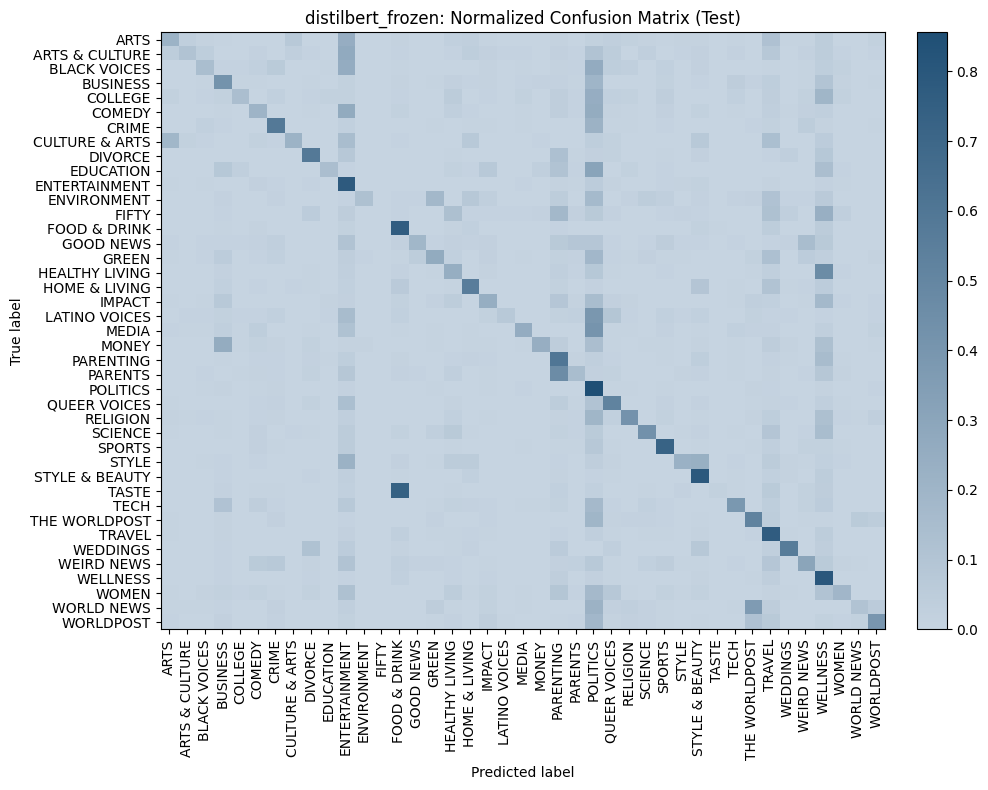

**Per-class metrics (sorted by F1):**

,class,precision,recall,f1-score,support
12,FIFTY,0.000000,0.000000,0.000000,140.0
31,TASTE,0.400000,0.019048,0.036364,210.0
19,LATINO VOICES,0.421053,0.070796,0.121212,113.0
1,ARTS & CULTURE,0.466667,0.104478,0.170732,134.0
39,WORLD NEWS,0.421053,0.110092,0.174545,218.0
4,COLLEGE,0.372093,0.140351,0.203822,114.0
11,ENVIRONMENT,0.695652,0.121212,0.206452,132.0
23,PARENTS,0.375000,0.144304,0.208410,395.0
9,EDUCATION,0.424242,0.140000,0.210526,100.0
2,BLACK VOICES,0.488722,0.143488,0.221843,453.0


**Final test metrics (overall):**

,experiment,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted
0,distilbert_frozen,0.56502,0.494423,0.370485,0.39411,0.56502,0.56502,0.56502,0.541911,0.56502,0.529644


#### distilbert_unfrozen — Test set evaluation (`20251223T010101Z`)

**What this shows:** Confusion matrix and per-class metrics on the held-out test set.**Why it matters:** It surfaces which categories are systematically confused and whether performance is consistent across labels.

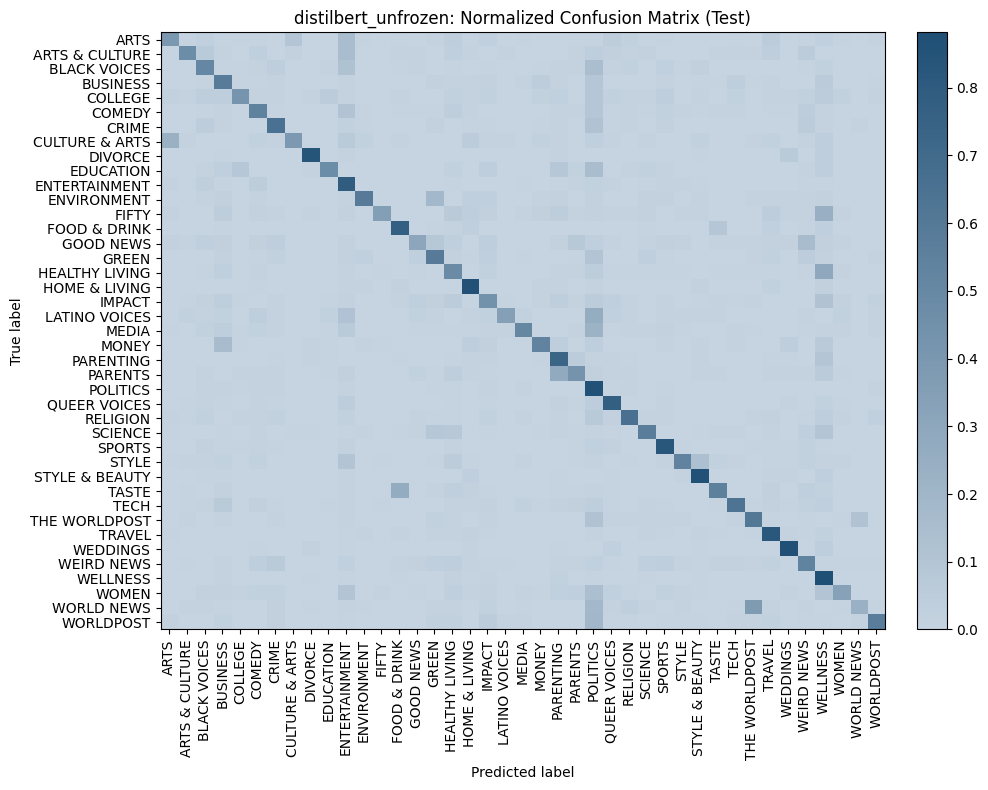

**Per-class metrics (sorted by F1):**

,class,precision,recall,f1-score,support
39,WORLD NEWS,0.476190,0.229358,0.309598,218.0
14,GOOD NEWS,0.420000,0.300000,0.350000,140.0
0,ARTS,0.461538,0.397351,0.427046,151.0
38,WOMEN,0.682353,0.332378,0.447013,349.0
19,LATINO VOICES,0.650000,0.345133,0.450867,113.0
4,COLLEGE,0.489796,0.421053,0.452830,114.0
7,CULTURE & ARTS,0.555556,0.388350,0.457143,103.0
18,IMPACT,0.479495,0.439306,0.458522,346.0
12,FIFTY,0.777778,0.350000,0.482759,140.0
23,PARENTS,0.567568,0.425316,0.486252,395.0


**Final test metrics (overall):**

,experiment,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted
0,distilbert_unfrozen,0.70686,0.638851,0.587905,0.604783,0.70686,0.70686,0.70686,0.701519,0.70686,0.699221


#### tfidf_dense — Test set evaluation (`20251222T184926Z`)

**What this shows:** Confusion matrix and per-class metrics on the held-out test set.**Why it matters:** It surfaces which categories are systematically confused and whether performance is consistent across labels.

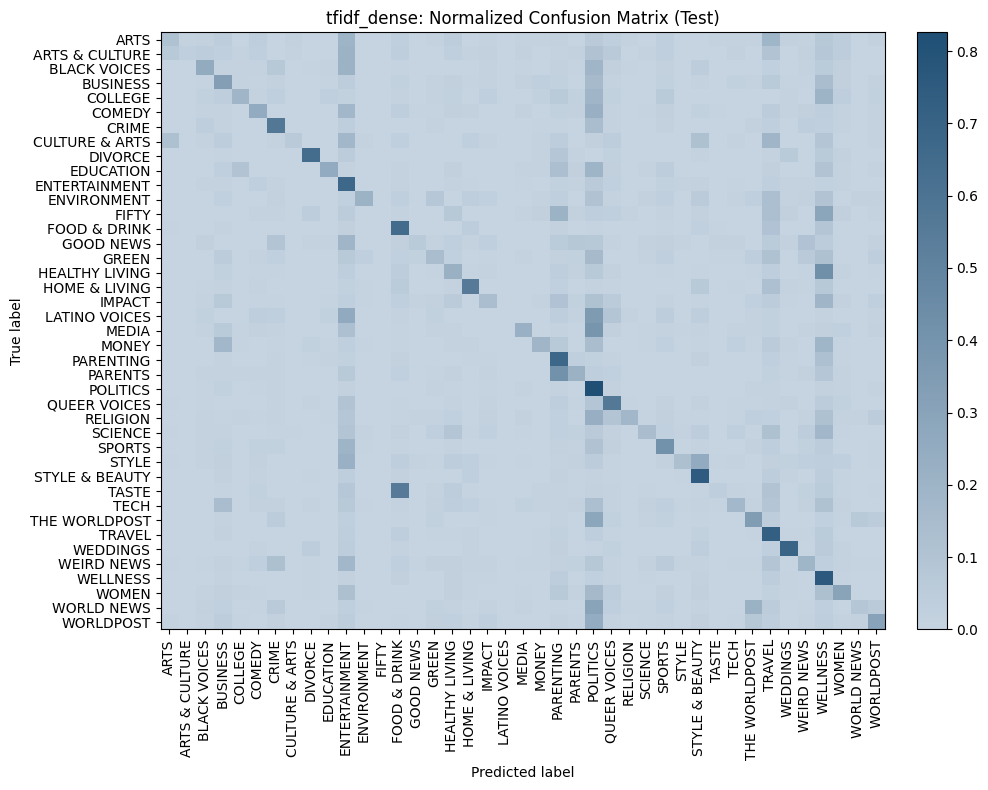

**Per-class metrics (sorted by F1):**

,class,precision,recall,f1-score,support
12,FIFTY,0.000000,0.000000,0.000000,140.0
19,LATINO VOICES,0.000000,0.000000,0.000000,113.0
1,ARTS & CULTURE,0.444444,0.029851,0.055944,134.0
31,TASTE,0.350000,0.033333,0.060870,210.0
7,CULTURE & ARTS,0.375000,0.058252,0.100840,103.0
14,GOOD NEWS,0.281250,0.064286,0.104651,140.0
39,WORLD NEWS,0.281250,0.082569,0.127660,218.0
0,ARTS,0.265625,0.112583,0.158140,151.0
15,GREEN,0.251656,0.145038,0.184019,262.0
18,IMPACT,0.317568,0.135838,0.190283,346.0


**Final test metrics (overall):**

,experiment,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted
0,tfidf_dense,0.522055,0.417084,0.321415,0.336983,0.522055,0.522055,0.522055,0.492977,0.522055,0.486625


#### tfidf_logreg — Test set evaluation (`20251222T183959Z`)

**What this shows:** Confusion matrix and per-class metrics on the held-out test set.**Why it matters:** It surfaces which categories are systematically confused and whether performance is consistent across labels.

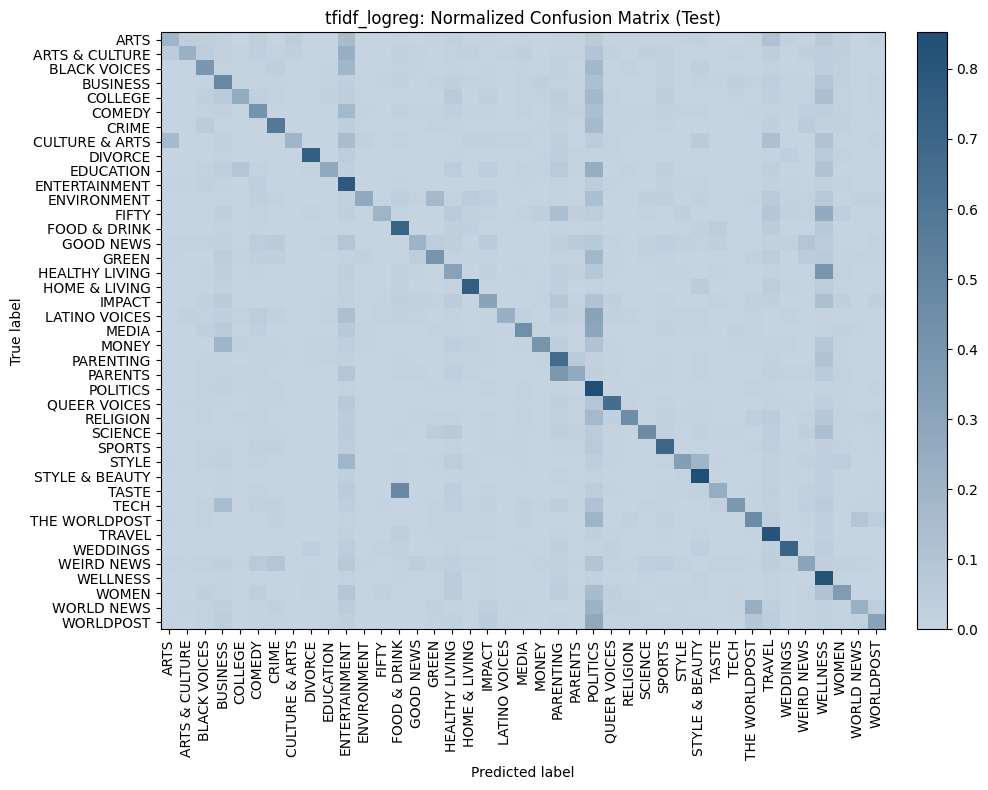

**Per-class metrics (sorted by F1):**

,class,precision,recall,f1-score,support
0,ARTS,0.365854,0.198675,0.257511,151.0
14,GOOD NEWS,0.371795,0.207143,0.266055,140.0
12,FIFTY,0.518519,0.200000,0.288660,140.0
7,CULTURE & ARTS,0.588235,0.194175,0.291971,103.0
39,WORLD NEWS,0.437500,0.224771,0.296970,218.0
4,COLLEGE,0.397260,0.254386,0.310160,114.0
1,ARTS & CULTURE,0.517241,0.223881,0.312500,134.0
31,TASTE,0.447368,0.242857,0.314815,210.0
9,EDUCATION,0.435484,0.270000,0.333333,100.0
19,LATINO VOICES,0.619048,0.230088,0.335484,113.0


**Final test metrics (overall):**

,experiment,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted
0,tfidf_logreg,0.622125,0.56775,0.454222,0.490883,0.622125,0.622125,0.622125,0.609461,0.622125,0.604485


In [6]:
test_summaries: List[Dict[str, Any]] = []

for run in EXPERIMENTS:
    exp = run.experiment
    run_dir = run.run_dir

    display(Markdown(f"#### {exp} — Test set evaluation (`{run_dir.name}`)"))
    display(Markdown(
        "**What this shows:** Confusion matrix and per-class metrics on the held-out test set."
        "**Why it matters:** It surfaces which categories are systematically confused and whether performance is consistent across labels."
    ))

    pred_path = run_dir / "predictions_test.csv"
    if not pred_path.exists():
        display(Markdown(f"Missing test predictions at `{pred_path}`; skipping."))
        continue

    df_pred = load_predictions_csv(pred_path)
    y_true = df_pred["y_true"].to_numpy(dtype=int)
    y_pred = df_pred["y_pred"].to_numpy(dtype=int)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
    plot_confusion_matrix_png(
        cm,
        CLASS_NAMES,
        title=f"{exp}: Normalized Confusion Matrix (Test)",
        filename=f"{exp}_confusion_matrix_test.png",
        normalize=True,
    )

    # Per-class table
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    df_report = (
        pd.DataFrame(report)
        .T
        .rename_axis("class")
        .reset_index()
    )

    # Keep class rows + summary rows in a clean order
    summary_rows = {"accuracy", "macro avg", "weighted avg"}
    df_classes = df_report[~df_report["class"].isin(summary_rows)].copy()
    df_summary = df_report[df_report["class"].isin(summary_rows)].copy()
    df_classes = df_classes.sort_values(by="f1-score", ascending=True)

    display(Markdown("**Per-class metrics (sorted by F1):**"))
    display(df_classes[["class", "precision", "recall", "f1-score", "support"]].head(25))

    # Overall summary
    overall = compute_overall_metrics(y_true, y_pred)
    display(Markdown("**Final test metrics (overall):**"))
    overall_df = pd.DataFrame([{"experiment": exp, **overall}])
    display(overall_df)

    test_summaries.append({"experiment": exp, "run_id": run_dir.name, **overall})

## Best model (based on test metrics)

We rank experiments primarily by **macro F1** (treating all classes equally), then break ties with accuracy.

In [7]:
if not test_summaries:
    raise RuntimeError("No test summaries computed; check that predictions_test.csv exists for experiments.")

df_best = pd.DataFrame(test_summaries)
df_best = df_best.sort_values(by=["f1_macro", "accuracy"], ascending=False).reset_index(drop=True)
display(df_best[["experiment", "run_id", "accuracy", "f1_macro", "f1_weighted", "f1_micro"]])

best = df_best.iloc[0]
print("Best experiment (by macro F1):")
print(f"- experiment: {best['experiment']}")
print(f"- run_id:     {best['run_id']}")
print(f"- accuracy:   {best['accuracy']:.4f}")
print(f"- macro F1:   {best['f1_macro']:.4f}")
print(f"- weighted F1:{best['f1_weighted']:.4f}")

,experiment,run_id,accuracy,f1_macro,f1_weighted,f1_micro
0,distilbert_unfrozen,20251223T010101Z,0.706860,0.604783,0.699221,0.706860
1,tfidf_logreg,20251222T183959Z,0.622125,0.490883,0.604485,0.622125
2,distilbert_frozen,20251222T190244Z,0.565020,0.394110,0.529644,0.565020
3,tfidf_dense,20251222T184926Z,0.522055,0.336983,0.486625,0.522055


Best experiment (by macro F1):
- experiment: distilbert_unfrozen
- run_id:     20251223T010101Z
- accuracy:   0.7069
- macro F1:   0.6048
- weighted F1:0.6992
